# **READ ME**

1. Run [Apify's Facebook Comments Scraper](https://apify.com/apify/facebook-comments-scraper). Make sure the settings are set to the following:

`Results amount: <round up the total number of comments seen on the post>`

`Check "Include comment replies"`

`Comments mode: Newest first`
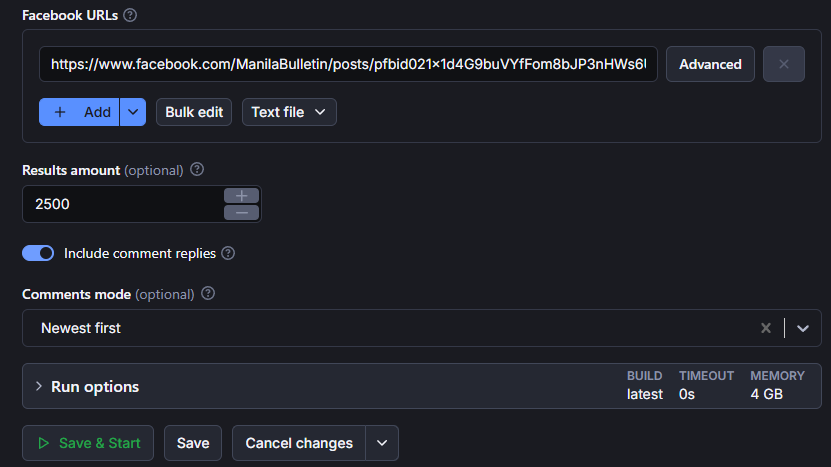

Start and Run the Apify Actor.

2. Export results as JSON. Make sure "All fields" is selected under the 'View' settings

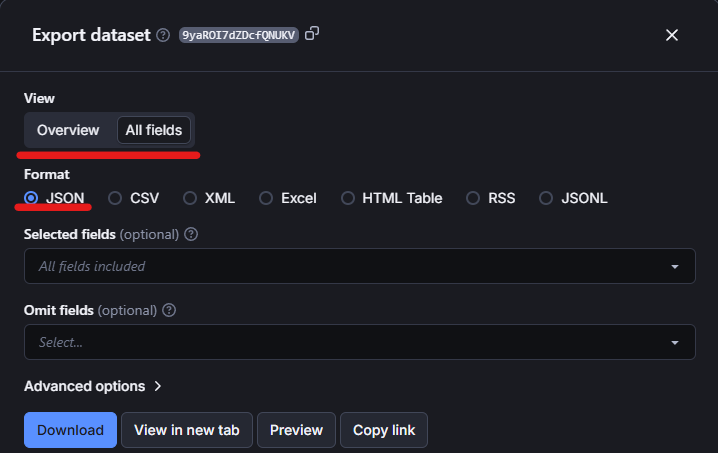


3. Upload all raw JSON files to [GDrive](https://drive.google.com/drive/folders/1lZ2w-h2oknLVsAQBVPmkD8LeEN2S-3PZ?usp=sharing) before proceeding. Please label accordingly and list down filename in the [Dataset Checklist](https://docs.google.com/spreadsheets/d/1q9mIvBEKCwXcrfvVfrIf0sPlK7-XnUmWxmV_-aAtYs4/edit?gid=980548996#gid=980548996)

4. Please note that these are the only values to be changed:

 `data = pd.read_json('<filename>.json') `

 `filename = "<letter>_<news-outlet>_cleaned.json" `

 `news_outlet = "<news_outlet>"`

 `date = datetime.strptime("<YYYY-MM-DD>", "%Y-%m-%d")`

 `time = datetime.strptime("<HH:MM:00>", "%H:%M:%S").time()`

5. Run all to clean JSON files

6. For any errors, please mark the post in the [Dataset Checklist](https://docs.google.com/spreadsheets/d/1q9mIvBEKCwXcrfvVfrIf0sPlK7-XnUmWxmV_-aAtYs4/edit?gid=980548996#gid=980548996)
7. Make sure number of scraped comments and number of cleaned comments match. If mismatch occurs, please mark the post in the [Dataset Checklist](https://docs.google.com/spreadsheets/d/1q9mIvBEKCwXcrfvVfrIf0sPlK7-XnUmWxmV_-aAtYs4/edit?gid=980548996#gid=980548996)
8. Upload all cleaned JSON files (located at the Files tab) to the [GDrive](https://drive.google.com/drive/folders/1BU3Hyrq-hDi72B-JMpY2NIauujK4dWfQ?usp=sharing). Place in approriate folder
 and observe proper naming convention: **letter_news-outlet_cleaned.json** (ex. a_mnl-bulletin_cleaned.json)





# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import json
import re

data = pd.read_json('ax_abscbn_uncleaned.json') #uncleaned JSON filename
filename = "ax_abscbn_cleaned.json" #cleaned JSON filename
news_outlet = "abscbn" #News outlet
# Date and Time Posted
date = datetime.strptime("2022-05-09", "%Y-%m-%d") #YYYY-MM-DD
time = datetime.strptime("23:52:00", "%H:%M:%S").time() #HH:MM:00 Use 24-hour format

In [ ]:
df = pd.DataFrame(data)

In [ ]:
if "replyToCommentId" not in df.columns:
  df["replyToCommentId"] = np.nan

In [ ]:
names = []
names = df["profileName"].unique().tolist()

In [ ]:
cleaned_data = {
    "page": news_outlet,
    "facebookPost": df.loc[0, "postTitle"],
    "postDate": date.strftime("%Y-%m-%d"),
    "postTime": time.strftime("%H:%M:%S"),
    "comments" : []
}

for index, row in df.iterrows():

    attachment = None

    if "attachments" in df.columns and pd.notna(row["attachments"]):
      att = row["attachments"]
      att_dict = att[0]

      if '__typename' in att_dict:
        if att_dict["__typename"] == "Video":
          if 'sticker_image' in att_dict:
            attachment = "GIF"
          elif 'blurred_image' in att_dict:
            attachment = "Video"
        elif att_dict["__typename"] == "GenericAttachmentMedia":
          attachment = "GIF"
        else:
          attachment = att_dict["__typename"]
      else:
        attachment = "Link"

    if pd.isna(row["replyToCommentId"]):
      text = row["text"] if pd.notna(row["text"]) else None
      if text is not None:
        for name in names:
          text = text.replace(name, "").strip()
      comment = {
        "commentID": row["id"],
        "userID": row["profileId"],
        "commentText": text,
        "commentDate": row["date"].strftime("%Y-%m-%d"),
        "commentTime": row["date"].strftime("%H:%M:%S"),
        "attachment": attachment,
        "likes": row["likesCount"],
        "replies" : []
      }
      cleaned_data["comments"].append(comment)

    if pd.notna(row["replyToCommentId"]):
      text = row["text"] if pd.notna(row["text"]) else None
      if text is not None:
        for name in names:
          text = text.replace(name, "").strip()
      reply = {
        "replyID": row["id"],
        "userID": row["profileId"],
        "replyText": text,
        "replyDate": row["date"].strftime("%Y-%m-%d"),
        "replyTime": row["date"].strftime("%H:%M:%S"),
        "attachment": attachment,
        "likes": row["likesCount"],
        "depth": row["threadingDepth"]
      }

      for comment in cleaned_data["comments"]:
        if comment["commentID"] == row["replyToCommentId"]:
            comment["replies"].append(reply)



In [ ]:
print(json.dumps(cleaned_data, indent=4))

{
    "page": "abscbn",
    "facebookPost": "Nagtipon sa Katipunan, Quezon City ang mga tagasuporta ng tambalang Robredo-Pangilinan sa gitna ng pagsubaybay nila sa partial at unofficial tally. #Halalan2022 | via Anjo Bagaoisan, ABS-CBN News\n\nBASAHIN ang kaugnay na ulat: https://news.abs-cbn.com/news/05/09/22/partial-unofficial-results-marcos-leads-2022-presidential-race",
    "postDate": "2022-05-09",
    "postTime": "23:52:00",
    "comments": [
        {
            "commentID": "Y29tbWVudDoxMDE2MDMwMTExMTA3MDE2OF81NTI4OTg5NDk1NzY0MDM=",
            "userID": "100013575332818",
            "commentText": "31 m na nga bomoto d pa kyo natuto",
            "commentDate": "2022-05-25",
            "commentTime": "22:06:10",
            "attachment": null,
            "likes": "0",
            "replies": []
        },
        {
            "commentID": "Y29tbWVudDoxMDE2MDMwMTExMTA3MDE2OF8zOTA2MzkzMjYzMTU4Njk=",
            "userID": "pfbid0kXhuu1JJAJRrS9xhyYUCiMzUS2j8A5S4b3zci22fK8LkGo9

In [ ]:
comment_count = 0
reply_count = 0

stack = [cleaned_data]

while stack:
    current = stack.pop()

    if isinstance(current, dict):
        if "commentID" in current:
            comment_count += 1
        if "replyID" in current:
            reply_count += 1
        stack.extend(current.values())

    elif isinstance(current, list):
        stack.extend(current)

num_items = len(df)

print("Number of scraped comments: ", num_items)
print("Number of cleaned comments:", comment_count + reply_count)

Number of scraped comments:  3855
Number of cleaned comments: 3855


In [ ]:
with open(filename, "w") as json_file:
    json.dump(cleaned_data, json_file, indent=4)

#**User-Centric JSON format**

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import os
from collections import Counter

# Define folder path containing JSON files
cleaned_folder_paths = [
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/ABS-CBN',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/GMA',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/INQUIRER.NET',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/MNL BULLETIN',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/PH STAR',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/cleaned/RAPPLER',

]

id_file_path = '/content/drive/MyDrive/I -TEAM FILES/Datasets/structured/all_ids.csv'

apify_folder_paths = [
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/abscbn',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/gma',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/inquirer',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/mnl bulletin',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/PH star',
    '/content/drive/MyDrive/I -TEAM FILES/Datasets/apify/rappler',
]

##**User Name and ID Mapping**

In [ ]:
all_profiles = []

for path in apify_folder_paths:
  for filename in os.listdir(path):
    if filename.endswith('.json'):
        file_path = os.path.join(path, filename)
        file_name = os.path.splitext(filename)[0]

        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            name_df = pd.DataFrame(data)
            name_df = name_df.drop_duplicates(subset=["id"])
            for _, row in name_df.iterrows():
                all_profiles.append({"Profile Name": row["profileName"], "Profile ID": row["profileId"]})

profiles_df = pd.DataFrame(all_profiles)
profiles_df = profiles_df.drop_duplicates(subset=["Profile Name", "Profile ID"])
print(f"Total profiles found {len(profiles_df)}")

Total profiles found 425998


In [ ]:
duplicates = profiles_df[profiles_df["Profile Name"].duplicated(keep=False)].sort_values(by="Profile Name")
duplicates

,Profile Name,Profile ID
22629,EMs-em Ditan Raro,pfbid02KL8tnJi5tYWAxxa1aRev84riMFGrYfxtcVkihdD...
416422,EMs-em Ditan Raro,pfbid0FjzDYMqiQVtngrdeeFMkxoE4YfwPoESmU5mWgAhk...
111184,'Ralph Yakusoku',pfbid03ia6x86wqPyCWAjZeQ5nLhno12qHjCSE1TzxxEfu...
671890,'Ralph Yakusoku',pfbid03TH51Q3VU5a7jHd8x4XcmQAJXEwRW47g95bWBDzp...
657658,'Ralph Yakusoku',pfbid027UsnVDF497wAcgqq9B9RLHBUvn2xbHNEzNwbwsh...
...,...,...
644682,ﹺ ﹺ ﹺ ...,pfbid0mvqwY12jhnYowiyPjj22dacug9zG1jfWQmrtxaZG...
697583,ﹺ ﹺ ﹺ ...,pfbid034tpdMEFreUiLZBBx1EY2m1E9ZqRQiikPDsCw1zi...
649642,ﹺ ﹺ ﹺ ﹺ,pfbid02H3fmnpcUB2MQHfgniYJkS8MWzcWrxknez2bjLAf...
280778,ﹺ ﹺ ﹺ ﹺ,pfbid0DCE4c9geKamT2AfRYuvmnEFc8x1LoR8ufwhBtLL4...


In [ ]:
import random

num_rows = len(profiles_df)

unique_randoms = set()

def get_random_id():
  while True:
      rnd = random.randint(1000000, 9999999)
      if rnd not in unique_randoms:
        unique_randoms.add(rnd)
        return rnd

id_map = {}
for name in profiles_df['Profile Name'].unique():
  id_map[name] = get_random_id()

profiles_df["Random ID"] = profiles_df["Profile Name"].map(id_map)

with open(id_file_path, "w", encoding="utf-8", newline="") as f:
    profiles_df.to_csv(f, index=False)

print("id maps uploaded")

id maps uploaded


In [ ]:
unique_length = len(profiles_df.drop_duplicates(subset=['Profile Name', 'Profile ID']))
print(f"Unique users identified: {unique_length}")

Unique users identified: 425998


In [ ]:
profiles_df.sort_values(by="Profile Name")

,Profile Name,Profile ID,Random ID
317208,Berj De Borja,pfbid0Tjyxij8K4c8unrudXErosAx6QzPF8U2gugPi8eiq...,7242699
22629,EMs-em Ditan Raro,pfbid02KL8tnJi5tYWAxxa1aRev84riMFGrYfxtcVkihdD...,1383985
416422,EMs-em Ditan Raro,pfbid0FjzDYMqiQVtngrdeeFMkxoE4YfwPoESmU5mWgAhk...,1383985
487907,Maybelle Gunday,pfbid0a9QaWUG28Tc6yS8tPgPK9bGc5YaEvUfUCPyMEk9V...,2629835
734198,'Elaine ELaine,pfbid0fgbRLWwCTonjNujQfRKbM7yRkk6nfgTgfiQdBUiZ...,7326557
...,...,...,...
449526,ﺟﯡژ ﭔﻧﯾهٛۂ ﺷﺣﻠﺂتهٛۂ ۂۦٰ۪ﮧ,pfbid0whRg6CxQFL2UrYYQKutRowA3wpDkmHEzmGpzJbnc...,5175336
25935,ﻋﺒﺪﺍﻟﻐﻔﺎﺭ ببار,pfbid0BZYDyVme4g2yArzThSpase85AinB3wa7GuMRrLg3...,5579353
554996,ﻵﻬﻫ ﻳﻕ,pfbid0CjuaDn5AGCWK27vaSeSFPpidquV5R5yYopiryr34...,8686372
430159,𝙇𝘼𝙂𝙐𝙉𝘼𝙇𝘼𝙆𝙀𝙏𝙑,100069353832789,3522896


In [ ]:
with open(id_file_path, 'r') as file:
  id_df = pd.read_csv(file)

In [ ]:
id_df.sort_values(by="Profile Name")

,Profile Name,Profile ID,Random ID
192024,Berj De Borja,pfbid0Tjyxij8K4c8unrudXErosAx6QzPF8U2gugPi8eiq...,7242699
18050,EMs-em Ditan Raro,pfbid02KL8tnJi5tYWAxxa1aRev84riMFGrYfxtcVkihdD...,1383985
240845,EMs-em Ditan Raro,pfbid0FjzDYMqiQVtngrdeeFMkxoE4YfwPoESmU5mWgAhk...,1383985
282628,Maybelle Gunday,pfbid0a9QaWUG28Tc6yS8tPgPK9bGc5YaEvUfUCPyMEk9V...,2629835
402975,'Elaine ELaine,pfbid0fgbRLWwCTonjNujQfRKbM7yRkk6nfgTgfiQdBUiZ...,7326557
...,...,...,...
254366,ﺟﯡژ ﭔﻧﯾهٛۂ ﺷﺣﻠﺂتهٛۂ ۂۦٰ۪ﮧ,pfbid0whRg6CxQFL2UrYYQKutRowA3wpDkmHEzmGpzJbnc...,5175336
20756,ﻋﺒﺪﺍﻟﻐﻔﺎﺭ ببار,pfbid0BZYDyVme4g2yArzThSpase85AinB3wa7GuMRrLg3...,5579353
316994,ﻵﻬﻫ ﻳﻕ,pfbid0CjuaDn5AGCWK27vaSeSFPpidquV5R5yYopiryr34...,8686372
247627,𝙇𝘼𝙂𝙐𝙉𝘼𝙇𝘼𝙆𝙀𝙏𝙑,100069353832789,3522896


In [ ]:
unique_length = len(id_df.drop_duplicates(subset=['Profile Name', 'Random ID']))
print(f"Unique users identified: {unique_length}")

Unique users identified: 328773


##**Extracting Comments**

In [ ]:
def get_ids(data):
  for comment in data["comments"]:
    structured_data.setdefault(comment["userID"], {"userID": comment["userID"], "comments": [], "label": None, "features": []})

    for reply in comment.get("replies", []):
      structured_data.setdefault(reply["userID"], {"userID": reply["userID"], "comments": [], "label": None, "features": []})

In [ ]:
from datetime import datetime
import pytz

philippine_tz = pytz.timezone('Asia/Manila')

def convert_to_pst(date_str, time_str):
  datetime_str = f"{date_str} {time_str}"
  dt_format = "%Y-%m-%d %H:%M:%S"
  dt_obj = datetime.strptime(datetime_str, dt_format)
  dt_obj = pytz.utc.localize(dt_obj)
  pst_dt = dt_obj.astimezone(philippine_tz)
  return pst_dt.strftime("%Y-%m-%d"), pst_dt.strftime("%H:%M:%S")

In [ ]:
def get_comments(data):

  for comment in data["comments"]:
    pst_date, pst_time = convert_to_pst(comment["commentDate"], comment["commentTime"])
    comment_entry = {
          "facebookPost": data["facebookPost"],
          "newsOutlet": data["page"],
          "postDate": data["postDate"],
          "postTime": data["postTime"],
          "commentID": comment["commentID"],
          "commentText": comment["commentText"],
          "commentDate": pst_date,
          "commentTime": pst_time,
          "attachment": comment["attachment"],
          "isReply": False,
          "parentCommentID": None,
          "depth": 0,
          "likes": comment["likes"]
    }
    structured_data[comment["userID"]]["comments"].append(comment_entry)

    for reply in comment.get("replies", []):
      pst_date, pst_time = convert_to_pst(reply["replyDate"], reply["replyTime"])
      reply_entry = {
          "facebookPost": data["facebookPost"],
          "newsOutlet": data["page"],
          "postDate": data["postDate"],
          "postTime": data["postTime"],
          "commentID": reply["replyID"],
          "commentText": reply["replyText"],
          "commentDate": pst_date,
          "commentTime": pst_time,
          "attachment": reply["attachment"],
          "isReply": True,
          "parentCommentID": comment["commentID"],
          "depth": reply["depth"],
          "likes": reply["likes"],
      }
      structured_data[reply["userID"]]["comments"].append(reply_entry)

In [ ]:
import traceback
import csv
import os
import json

def process_file(filepath):
  try:
    with open(filepath, 'r', encoding='utf-8') as f:
      data=json.load(f)
      get_ids(data)
      get_comments(data)
  except Exception as e:
    print(f"Error in file: {filepath} : {e}")
    print(traceback.format_exc())

In [ ]:
structured_data = {}

# Iterate through all JSON files in the folder
for folder in cleaned_folder_paths:
  print(f"Restructuring: {os.path.basename(folder)}")
  for filename in os.listdir(folder):
    if filename.endswith('.json'):
        process_file(os.path.join(folder, filename))

  output_data = list(structured_data.values())

  print(f"Total_comments: {sum(len(user['comments']) for user in output_data)}")

  struct_file_path = f"/content/drive/MyDrive/I -TEAM FILES/Datasets/structured/{os.path.basename(folder)}.json"

  with open(struct_file_path, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, indent=4)

  print(f"Structured JSON file saved: {struct_file_path}")

  structured_data.clear()

Restructuring: ABS-CBN
Total_comments: 148100
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/ABS-CBN.json
Restructuring: GMA
Total_comments: 299830
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/GMA.json
Restructuring: INQUIRER.NET
Total_comments: 77395
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/INQUIRER.NET.json
Restructuring: MNL BULLETIN
Total_comments: 82948
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/MNL BULLETIN.json
Restructuring: PH STAR
Total_comments: 76605
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/PH STAR.json
Restructuring: RAPPLER
Total_comments: 51016
Structured JSON file saved: /content/drive/MyDrive/I -TEAM FILES/Datasets/structured/RAPPLER.json


##**Anonymized User IDs**

In [ ]:
from google.colab import drive
import csv
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
unmatched_ids = set()

In [ ]:
maps = {}
struct_folder = "/content/drive/MyDrive/I -TEAM FILES/Datasets/structured"
output_folder = "/content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized"
id_list_folder = "/content/drive/MyDrive/I -TEAM FILES/Datasets/user ids"


with open(id_file_path, mode='r', encoding ="utf-8") as f:
  reader = csv.DictReader(f)
  for row in reader:
    maps[row["Profile ID"]] = row["Random ID"]

for filename in os.listdir(struct_folder):
  if filename.endswith('.json'):
    file_path = os.path.join(struct_folder, filename)
    with open(file_path, 'r', encoding ="utf-8") as f:
      data=json.load(f)

      filtered_data = []
      unmatched_count = 0

      for entry in data:
          if entry["userID"] in maps:
              entry["userID"] = maps[entry["userID"]]
              filtered_data.append(entry)
          else:
              unmatched_ids.add(entry["userID"])
              unmatched_count += 1

      print(f"Processing: {os.path.basename(filename)}")
      print(f"Total entries after filtering: {len(filtered_data)}")
      print(f"Total unmatched IDs: {unmatched_count}")

      if filtered_data:
          output_file = os.path.join(output_folder, os.path.basename(filename))
          with open(output_file, "w", encoding="utf-8") as f:
              json.dump(filtered_data, f, indent=4, ensure_ascii=False)
          print(f"Saved anonymized file: {output_file}")
      else:
          print("No entries with matched userID. Skipping file.")



Processing: ABS-CBN.json
Total entries after filtering: 101090
Total unmatched IDs: 0
Saved anonymized file: /content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized/ABS-CBN.json
Processing: GMA.json
Total entries after filtering: 180143
Total unmatched IDs: 0
Saved anonymized file: /content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized/GMA.json
Processing: INQUIRER.NET.json
Total entries after filtering: 43672
Total unmatched IDs: 181
Saved anonymized file: /content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized/INQUIRER.NET.json
Processing: MNL BULLETIN.json
Total entries after filtering: 40066
Total unmatched IDs: 0
Saved anonymized file: /content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized/MNL BULLETIN.json
Processing: PH STAR.json
Total entries after filtering: 49060
Total unmatched IDs: 279
Saved anonymized file: /content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized/PH STAR.json
Processing: RAPPLER.json
Total entries after filtering: 32098
Total unmatched IDs: 0
Saved a

In [ ]:
len(unmatched_ids)

460

##**Merging JSON files**

In [ ]:
from google.colab import drive
import os
import json

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
anon_folder = "/content/drive/MyDrive/I -TEAM FILES/Datasets/anonymized"


merged_data = {}

for filename in os.listdir(anon_folder):
  if filename.endswith('.json'):
    file_path = os.path.join(anon_folder, filename)
    with open(file_path, "r", encoding="utf-8") as f:
      try:
        data = json.load(f)
        for entry in data:
          user_id = entry["userID"]
          if user_id in merged_data:
            merged_data[user_id]["comments"].extend(entry["comments"])
          else:
            merged_data[user_id] = {
                "userID": user_id,
                "comments": entry["comments"],
                "label": entry["label"],
                "features": entry["features"]
            }
      except json.JSONDecodeError:
        print(f"Skipping {filename}: Invalid JSON")
        continue

output = list(merged_data.values())

output_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Merged).json"
with open(output_path, "w", encoding="utf-8") as out_file:
    json.dump(output, out_file, indent=4, ensure_ascii=False)

print(f"Merging complete! Output saved at: {output_path}")


Merging complete! Output saved at: /content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Merged).json


In [ ]:
total_comments = sum(len(user_data.get("comments", [])) for user_data in merged_data.values())

print(f"Total number of comments: {total_comments}")

Total number of comments: 735883


In [ ]:
import json

def flatten_json(nested_json):
    flattened = []

    for entry in nested_json:
        user_id = entry["userID"]
        label = entry["label"]
        features = entry["features"]

        for comment in entry["comments"]:
            flattened.append({
                "userID": user_id,
                "facebookPost": comment["facebookPost"],
                "newsOutlet": comment["newsOutlet"],
                "postDate": comment["postDate"],
                "postTime": comment["postTime"],
                "commentID": comment["commentID"],
                "commentText": comment["commentText"],
                "commentDate": comment["commentDate"],
                "commentTime": comment["commentTime"],
                "attachment": comment["attachment"],
                "isReply": comment["isReply"],
                "parentCommentID": comment["parentCommentID"],
                "depth": comment["depth"],
                "likes": comment["likes"],
                "label": label,
                "features": features
            })

    return flattened


with open("/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Merged).json", "r", encoding="utf-8") as f:
    data = json.load(f)

flattened_data = flatten_json(data)


with open("/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Flattened).json", "w", encoding="utf-8") as f:
    json.dump(flattened_data, f, indent=4)

print("Flattened JSON saved to flattened.json")


Flattened JSON saved to flattened.json


In [ ]:
len(flattened_data)

735883